# Quality Control

## Load count matrix

In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [2]:
import rpy2
%load_ext rpy2.ipython

In [3]:
%%R -o sce
library(ensembldb)
library(EnsDb.Hsapiens.v86)

# Read the combined, empty-drop filtered count matrix RDS file and output SingleCellExperiment object to Python
rds_path <- "../raw_data_processing/results/alevin/mtx_conversions/combined_emptydrops_filter_matrix.sce.rds"
sce <- readRDS(rds_path)

# Extract Ensembl gene IDs
ensembl_ids <- rownames(sce)

# Convert Ensembl IDs to gene symbols
gene_symbols <- mapIds(EnsDb.Hsapiens.v86, 
                       keys = ensembl_ids, 
                       column = "SYMBOL", 
                       keytype = "GENEID", 
                       multiVals = "first")

# Convert Ensembl IDs to full gene names
gene_names <- mapIds(EnsDb.Hsapiens.v86, 
                     keys = ensembl_ids, 
                     column = "GENENAME", 
                     keytype = "GENEID", 
                     multiVals = "first")

# Add gene symbols and gene names to rowData
rowData(sce)$gene_symbol <- gene_symbols
rowData(sce)$gene_name <- gene_names

# Check the first few mappings
head(rowData(sce))



R[write to console]: Loading required package: BiocGenerics

R[write to console]: 
Attaching package: ‘BiocGenerics’


R[write to console]: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


R[write to console]: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


R[write to console]: Loading required package: GenomicRanges

R[write to console]: Loading required package: stats4

R[write to console]: Loading required package: S4Vectors

R[write to console]: 
Attaching package: ‘S4Vectors’


R[write to console]: The following object is masked from ‘package:

DataFrame with 6 rows and 3 columns
                  gene_versions gene_symbol   gene_name
                    <character> <character> <character>
ENSG00000001461 ENSG00000001461      NIPAL3      NIPAL3
ENSG00000010072 ENSG00000010072       SPRTN       SPRTN
ENSG00000008118 ENSG00000008118      CAMK1G      CAMK1G
ENSG00000009780 ENSG00000009780      FAM76A      FAM76A
ENSG00000048707 ENSG00000048707      VPS13D      VPS13D
ENSG00000041988 ENSG00000041988       THAP3       THAP3


In [4]:
print(sce)

class: SingleCellExperiment 
dim: 236796 1189 
metadata(0):
assays(1): X
rownames(236796): ENSG00000001461 ENSG00000010072 ... ENSG00000310554-A
  ENSG00000310555-A
rowData names(3): gene_versions gene_symbol gene_name
colnames(1189): GCATGTACAATCTACG_Hair_graft_5_emptydrops_filter
  TGACAACAGATGTGGC_Hair_graft_5_emptydrops_filter ...
  CGATTGATCTGTGCAA_Hair_graft_5_emptydrops_filter
  ACCTTTAGTTTAGGAA_Hair_graft_5_emptydrops_filter
colData names(3): sample fastq_1 fastq_2
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):



In [5]:
# Convert the SingleCellExperiment object to AnnData object
import anndata2ri
from rpy2.robjects import r
from rpy2.robjects.conversion import localconverter

with localconverter(anndata2ri.converter):
    adata = r('as(sce, "SingleCellExperiment")')

print(adata)

AnnData object with n_obs × n_vars = 1189 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2'
    var: 'gene_versions', 'gene_symbol', 'gene_name'


In [6]:
import pandas as pd
gene_df = pd.DataFrame(adata.var)
gene_df

,gene_versions,gene_symbol,gene_name
ENSG00000001461,ENSG00000001461,NIPAL3,NIPAL3
ENSG00000010072,ENSG00000010072,SPRTN,SPRTN
ENSG00000008118,ENSG00000008118,CAMK1G,CAMK1G
ENSG00000009780,ENSG00000009780,FAM76A,FAM76A
ENSG00000048707,ENSG00000048707,VPS13D,VPS13D
...,...,...,...
ENSG00000310550-A,ENSG00000310550-A,None,None
ENSG00000310552-A,ENSG00000310552-A,None,None
ENSG00000310553-A,ENSG00000310553-A,None,None
ENSG00000310554-A,ENSG00000310554-A,None,None


## Filter low quality cells

In [7]:
# mitochondrial genes
adata.var['mt'] = adata.var['gene_symbol'].str.startswith("MT-", na=False)
# ribosomal genes
adata.var['ribo'] = adata.var['gene_symbol'].str.startswith(("RPS", "RPL"), na=False)
# hemoglobin genes
adata.var['hb'] = adata.var['gene_symbol'].str.contains("^HB[^(P)]", na=False)

In [8]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 1189 × 236796
    obs: 'sample', 'fastq_1', 'fastq_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

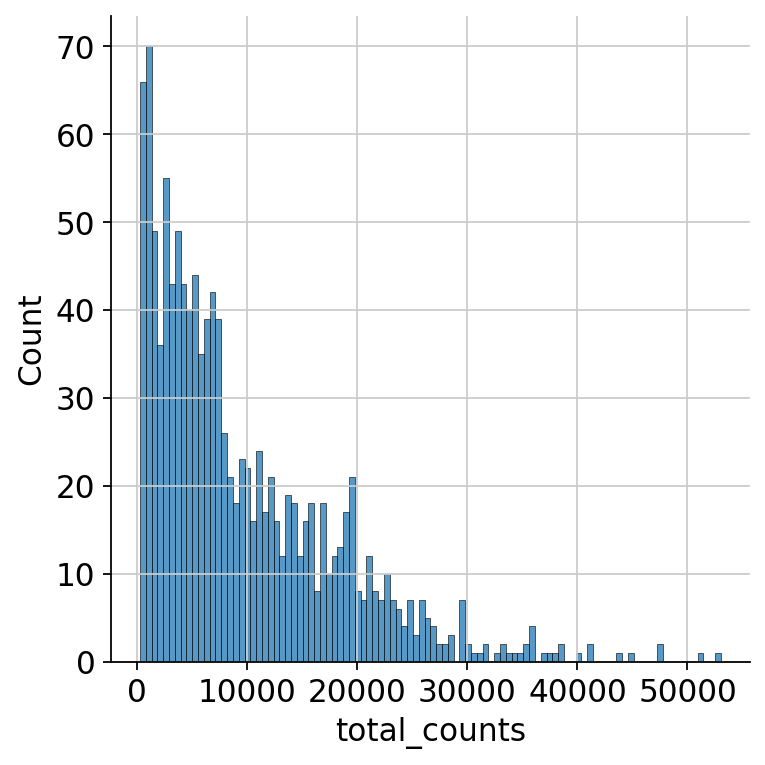

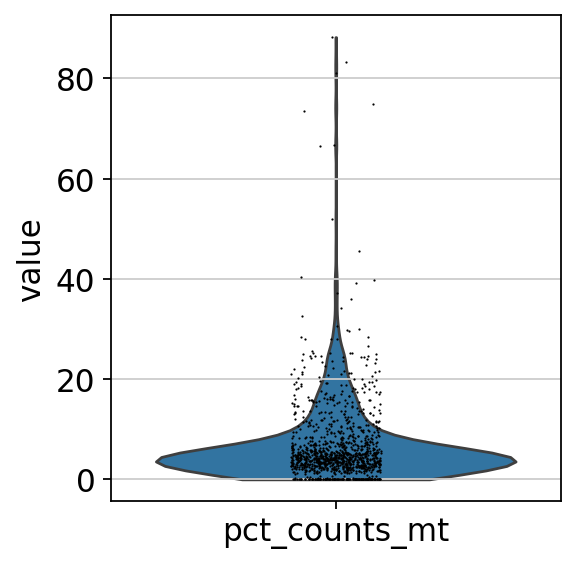

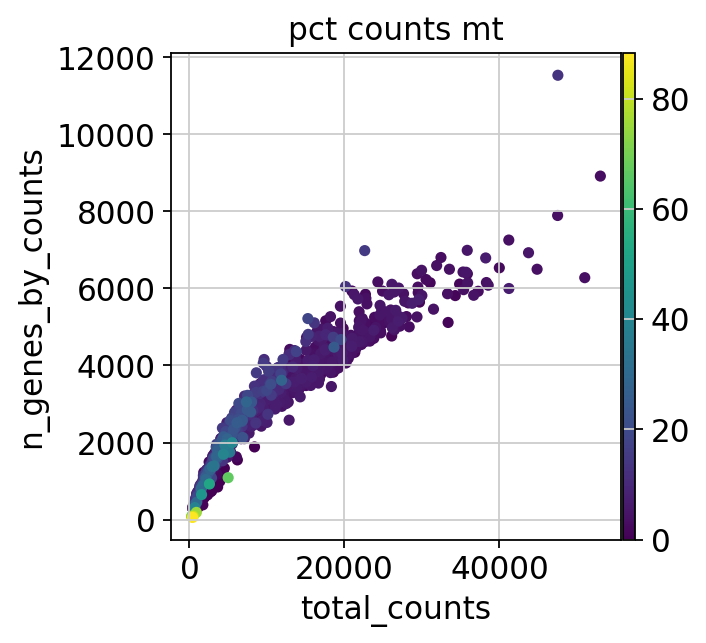

In [9]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [10]:
# Outlier thresholding based on median absolute deviations (MADs)
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [11]:
# apply this function to the log1p_total_counts, log1p_n_genes_by_counts and
# pct_counts_in_top_20_genes QC covariates each with a threshold of 5 MADs
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    1139
True       50
Name: count, dtype: int64

In [12]:
# Mark cells with % mitochondrial counts > 3 MADs
# or mitochondrial counts > 8%
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    909
True     280
Name: count, dtype: int64

In [13]:
# filter our AnnData object based on these two additional columns
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 1189
Number of cells after filtering of low quality cells: 892


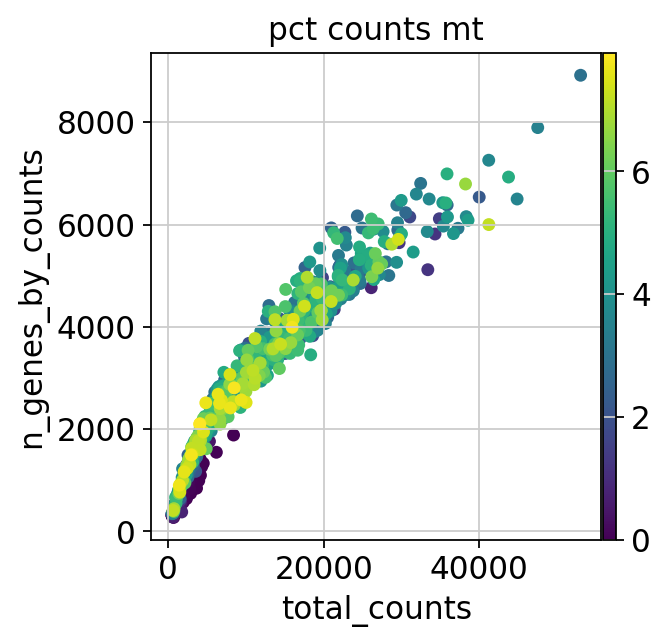

In [14]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Correction of ambient RNA

In [15]:
import logging

# import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
# import rpy2.robjects as ro

rcb.logger.setLevel(logging.ERROR)
# ro.pandas2ri.activate()
# anndata2ri.activate()

In [16]:
%%R
library(SoupX)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [17]:
# generate a copy of our AnnData object, normalize and log1p transform it
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

In [18]:
sc.pp.pca(adata_pp) # compute principle components
sc.pp.neighbors(adata_pp) # generate KNN graph
sc.tl.leiden(adata_pp, key_added="soupx_groups") # run leiden clustering

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

/tmp/ipykernel_15335/2847450567.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp, key_added="soupx_groups") # run leiden clustering


In [19]:
# delete AnnData object copy
del adata_pp

In [20]:
# save the cell IDs, gene IDs, and the counts of the filtered count matrix
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [21]:
%%R -o raw_sce
# Read the combined, raw count matrix RDS file and output SingleCellExperiment object to Python
rds_path <- "../raw_data_processing/results/alevin/mtx_conversions/combined_raw_matrix.sce.rds"
raw_sce <- readRDS(rds_path)

In [22]:
# convert raw count matrix from SCE to AnnData and extract counts
with localconverter(anndata2ri.converter):
    adata_raw = r('as(raw_sce, "SingleCellExperiment")')

data_tod = adata_raw.X.T
del adata_raw

In [23]:
import rpy2.robjects as ro

with (ro.default_converter + anndata2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(data)
  r_data_tod = ro.conversion.get_conversion().py2rpy(data_tod)

In [24]:
%%R -i r_data -i r_data_tod -i genes -i cells -i soupx_groups -o r_out 

# specify row and column names of data
data <- r_data
data_tod <- r_data_tod
rownames(data) = genes
colnames(data) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data, "sparseMatrix")
data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
r_out = adjustCounts(sc, roundToInt = TRUE)

In [25]:
with (ro.default_converter + anndata2ri.converter).context():
  out = ro.conversion.get_conversion().rpy2py(r_out)

In [26]:
# add a new layer to the AnnData object with the SoupX background RNA-corrected count matrix
# and replace the current count matrix with this corrected count matrix
adata.layers["counts"] = adata.X
adata.layers["soupX_counts"] = out.T
adata.X = adata.layers["soupX_counts"]

## Doublet Detection

In [27]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)

In [28]:
data_mat = adata.X.T

In [29]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data_mat = ro.conversion.get_conversion().py2rpy(data)

In [30]:
%%R -i r_data_mat -o r_doublet_score -o r_doublet_class
# Use scDblFinder to detect doublets
set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=r_data_mat),
    ) 
)
r_doublet_score = sce$scDblFinder.score
r_doublet_class = sce$scDblFinder.class

In [31]:
with (ro.default_converter + anndata2ri.converter).context():
  doublet_score = ro.conversion.get_conversion().rpy2py(r_doublet_score)
  doublet_class = ro.conversion.get_conversion().rpy2py(r_doublet_class)

In [32]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    863
doublet     29
Name: count, dtype: int64

In [35]:
# save the dataset to file
import anndata
anndata.settings.allow_write_nullable_strings = True
adata.write("quality_control.h5ad.gz", compression='gzip')